In [1]:
import sys
print(sys.executable)



d:\Project Ch 1\.venv\Scripts\python.exe


In [2]:
!"d:\Project Ch 1\.venv\Scripts\python.exe" -m pip install numpy pandas matplotlib scikit-learn


In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [4]:
le=LabelEncoder()

In [5]:
df=pd.read_csv('./Data/Titanic-Dataset.csv')


In [6]:
# df.info()
# df.describe()
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
x=df[[ 'Pclass', 'Sex', 'Age', 'SibSp','Parch','Fare']]
x['Sex'].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

In [10]:
y.isnull().sum()
# y.head()

np.int64(0)

In [ ]:
x['Sex']=le.fit_transform(x['Sex'])
x['Sex']

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5856\2464888105.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Sex']=le.fit_transform(x['Sex'])


0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int64

In [ ]:
x['Age'].fillna(x['Age'].mean(),inplace=True)
x['Age'].isna().sum()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24256\1332159516.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['Age'].fillna(x['Age'].mean(),inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24256\1332159516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Age'].fillna(x['Age'].mean(),inplace=True)


np.int64(0)

In [9]:
y=df['Survived']

In [12]:
survived_count=y.value_counts()
survived_count

Survived
0    549
1    342
Name: count, dtype: int64

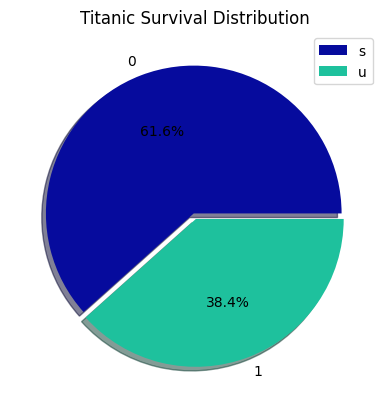

In [32]:
plt.pie(survived_count.values,labels=survived_count.index,colors=["#060B9D","#1EC19D"],autopct="%1.1f%%",explode=[0.02,0.02],shadow=True)
plt.title("Titanic Survival Distribution")
plt.legend("survived_count.index")


Machine learning Algorithms

In [ ]:
print(x.shape)
print(y.shape)


(891, 6)
(891,)


In [ ]:
x = x.reset_index(drop=True)
y = y.reset_index(drop=True).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(x.shape)
print(y.shape)


(891, 6)
(891,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

In [ ]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
model.score(x_test,y_test)

0.7988826815642458

In [ ]:
from sklearn.metrics import confusion_matrix


In [ ]:
score_matrix=confusion_matrix(y_test,model.predict(x_test))
score_matrix

array([[92, 13],
       [23, 51]])

In [ ]:
import joblib
joblib.dump(model,"titanicmodel.pkl")

['titanicmodel.pkl']